# VRChat retention, Part 3: designing a fair test

Companion notebook to Part 3. It rebuilds every number on the page; section numbers follow the page.
It reads `data/retention_table.csv` (saved by the Part 1 notebook) and the review file for the newest months.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from scipy.stats import norm

d = pd.read_csv("data/retention_table.csv", parse_dates=["start", "last_played"])
DOWNLOAD = pd.Timestamp("2026-08-28 06:39")
END = DOWNLOAD - pd.Timedelta(days=365)                    # analysis end, as in Part 1
hours = d["author_playtime_at_review"] / 60
negative = d["voted_up"] == False
protest = (d["start"] >= "2022-07-25") & (d["start"] < "2022-08-01")     # the July 2022 protest week
new_player = (hours >= 1) & (hours < 20)

target = d[new_player & negative & ~protest]               # new players with a negative review
still = target[target["group"] != "already gone"]          # still playing at the review
gone = target[target["group"] == "already gone"]
km_all = KaplanMeierFitter().fit(target["T"], target["event"])
km_still = KaplanMeierFitter().fit(still["T"], still["event"])
SHARE_STILL = len(still) / len(target)
BASE_ALL, BASE_STILL = km_all.predict(90), km_still.predict(90)

## 2. Who to test, and when

In [2]:
print(f"new players (1 to 20 h) with a negative review, outside the protest week: {len(target):,}")
print(f"already stopped when they wrote the review: {1 - SHARE_STILL:.1%}")
print(f"still playing at day 90, everyone: {BASE_ALL:.1%}; if playing at the review: {BASE_STILL:.1%}")

under_1h = d[(hours < 1) & negative & ~protest]
print(f"under 1 hour, negative review: {(under_1h['group'] == 'already gone').mean():.0%} already stopped")
all_weeks = d[new_player & negative]
print(f"already stopped: protest week {(all_weeks.loc[protest[all_weeks.index], 'group'] == 'already gone').mean():.1%}, "
      f"all weeks {(all_weeks['group'] == 'already gone').mean():.1%} (Part 1's figure)")

new players (1 to 20 h) with a negative review, outside the protest week: 12,629
already stopped when they wrote the review: 27.3%
still playing at day 90, everyone: 58.0%; if playing at the review: 79.8%
under 1 hour, negative review: 50% already stopped
already stopped: protest week 34.6%, all weeks 28.7% (Part 1's figure)


How fast leavers go, among players still playing at the review.

In [3]:
S = {t: km_still.predict(t) for t in (1 / 24, 1, 3, 90)}
leave90 = 1 - S[90]
print(f"of the leaving by day 90: {(1 - S[1]) / leave90:.0%} on the first day, {(1 - S[3]) / leave90:.0%} within 3 days")
leavers = still[(still["event"] == 1) & (still["T"] < 90)]
in_hour = (leavers["T"] < 1 / 24).sum()
print(f"leavers by day 90 whose last session was within an hour of the review: {in_hour} of {len(leavers):,} ({in_hour / len(leavers):.0%})")

of the leaving by day 90: 37% on the first day, 47% within 3 days
leavers by day 90 whose last session was within an hour of the review: 364 of 1,831 (20%)


A 7 day login rule (at least one session in the 7 days before the review) lets in the already gone who wrote within a week of their final session.

In [4]:
week_gone = int(((gone["start"] - gone["last_played"]).dt.total_seconds() <= 7 * 86400).sum())
S7 = len(still) / (len(still) + week_gone)                 # share still playing among those let in, if every player still playing passes
SHARE7 = (len(still) + week_gone) / len(target)
print(f"already gone who wrote within 7 days of their final session: {week_gone:,} of {len(gone):,} ({week_gone / len(gone):.0%})")
print(f"if everyone still playing passes: {S7:.0%} of those let in are still playing, {1 - S7:.1%} already gone")

already gone who wrote within 7 days of their final session: 1,006 of 3,450 (29%)
if everyone still playing passes: 90% of those let in are still playing, 9.9% already gone


The test triggers at the first eligible negative review per player (newly posted or edited to negative). The sizing uses each review as it finally stands, with the clock at its last edit; for reviews never edited the two moments coincide.

In [5]:
print(f"reviews never edited, so trigger and sizing clock coincide: {(~target['edited']).mean():.1%} of all, {(~still['edited']).mean():.1%} of those still playing")

reviews never edited, so trigger and sizing clock coincide: 82.4% of all, 82.5% of those still playing


## 4. How big the test has to be
Two shares, two sided at 95% confidence, 80% power. The effect is stated as the share of would be leavers the help keeps. The Steam day 90 share is a planning proxy: Steam keeps only each player's last session, so it can't reproduce the login measure (any play from day 76 to day 90).

In [6]:
Z = norm.ppf(0.975) + norm.ppf(0.80)


def per_group(base, lift):
    """People per group to detect a lift from base, two shares, 95% two sided, 80% power."""
    return Z ** 2 * (base * (1 - base) + (base + lift) * (1 - base - lift)) / lift ** 2


print(f"leave by day 90, if playing at the review: {leave90:.1%}; keeping 1 in 5 of them lifts day 90 by {100 * 0.2 * leave90:.1f} points")
designs = {"only players still playing (best case)": 1.0, "the plan's 7 day rule": S7, "already gone included": SHARE_STILL}
rows = []
for name, share in designs.items():                         # the already gone can't be helped and aren't playing at day 90
    base, lift = share * BASE_STILL, share * 0.2 * leave90
    rows.append({"who is let in": name, "already gone": f"{1 - share:.1%}", "day 90 share without help": f"{base:.1%}",
                 "lift for 1 in 5, points": round(100 * lift, 1), "per group": round(per_group(base, lift))})
print(pd.DataFrame(rows).to_string(index=False))

best, plan = per_group(BASE_STILL, 0.2 * leave90), per_group(S7 * BASE_STILL, S7 * 0.2 * leave90)
lift_only = per_group(BASE_STILL, S7 * 0.2 * leave90)
print(f"plan: the smaller lift alone (1 / {S7:.2f} squared = {1 / S7 ** 2:.2f}) gives {lift_only:,.0f}; "
      f"with the lower day 90 share {plan:,.0f} ({plan / best:.1f} times the best case)")

leave by day 90, if playing at the review: 20.2%; keeping 1 in 5 of them lifts day 90 by 4.0 points
                         who is let in already gone day 90 share without help  lift for 1 in 5, points  per group
only players still playing (best case)         0.0%                     79.8%                      4.0       1429
                 the plan's 7 day rule         9.9%                     71.9%                      3.6       2293
                 already gone included        27.3%                     58.0%                      2.9       4393
plan: the smaller lift alone (1 / 0.90 squared = 1.23) gives 1,775; with the lower day 90 share 2,293 (1.6 times the best case)


           still playing  plan  already gone included  included / still playing
keeps 10%           5970  9385                  17683                       3.0
keeps 20%           1429  2293                   4393                       3.1
keeps 30%            605   994                   1939                       3.2
keeps 50%            194   338                    686                       3.5


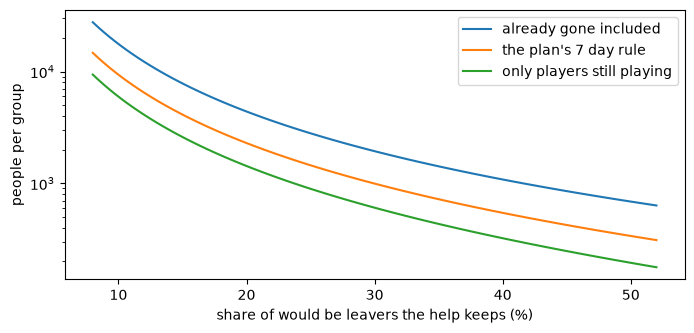

In [7]:
KEEPS = [0.1, 0.2, 0.3, 0.5]
size_live = lambda k: per_group(BASE_STILL, k * leave90)
size_plan = lambda k: per_group(S7 * BASE_STILL, S7 * k * leave90)
size_all = lambda k: per_group(BASE_ALL, SHARE_STILL * k * leave90)
table = pd.DataFrame({"still playing": [size_live(k) for k in KEEPS], "plan": [size_plan(k) for k in KEEPS],
                      "already gone included": [size_all(k) for k in KEEPS]}, index=[f"keeps {k:.0%}" for k in KEEPS]).round().astype(int)
table["included / still playing"] = (table["already gone included"] / table["still playing"]).round(1)
print(table.to_string())

kk = np.linspace(0.08, 0.52, 100)
plt.figure(figsize=(8, 3.5))
for name, f in (("already gone included", size_all), ("the plan's 7 day rule", size_plan), ("only players still playing", size_live)):
    plt.plot(100 * kk, [f(k) for k in kk], label=name)
plt.yscale("log")
plt.xlabel("share of would be leavers the help keeps (%)")
plt.ylabel("people per group")
plt.legend()
plt.show()

In [8]:
RATE = 200                                                 # negative reviews from new players a month (section 5)
months = lambda n, share: 2 * n / (RATE * share)
print(f"keeping 1 in 10, best case: {size_live(0.1):,.0f} per group, about {months(size_live(0.1), SHARE_STILL) / 12:.0f} years "
      f"at {RATE * SHARE_STILL:.0f} a month still playing at the review")

up = d[new_player & (d["voted_up"] == True) & ~protest & (d["group"] != "already gone")]
UP90 = KaplanMeierFitter().fit(up["T"], up["event"]).predict(90)
gap = UP90 - BASE_STILL
print(f"day 90 among players still playing: thumbs up {UP90:.1%}, thumbs down {BASE_STILL:.1%}, a {100 * gap:.1f} point gap; "
      f"closing it keeps about 1 in {leave90 / gap:.0f} leavers")
year_up = KaplanMeierFitter().fit(up["T"], up["event"]).predict(365)
print(f"a year later: thumbs up {year_up:.1%}, thumbs down {km_still.predict(365):.1%}, a {100 * (year_up - km_still.predict(365)):.1f} point gap "
      f"(Part 2's per band model gives about 5)")

keeping 1 in 10, best case: 5,970 per group, about 7 years at 145 a month still playing at the review
day 90 among players still playing: thumbs up 82.6%, thumbs down 79.8%, a 2.8 point gap; closing it keeps about 1 in 7 leavers
a year later: thumbs up 67.2%, thumbs down 62.8%, a 4.4 point gap (Part 2's per band model gives about 5)


Timing: help that lands later can only keep leavers still there when it lands.

In [9]:
for label, t in (("at the review", 0), ("an hour later", 1 / 24), ("a day later", 1), ("three days later", 3)):
    there = leave90 if t == 0 else S[t] - S[90]               # leavers still there when the help lands
    b, p = per_group(BASE_STILL, 0.2 * there), per_group(S7 * BASE_STILL, S7 * 0.2 * there)
    print(f"help {label:<16}: best case {b:>6,.0f} ({b / best:.1f}x), plan {p:>6,.0f} ({p / plan:.1f}x, {months(p, SHARE7):.1f} months of reviews)")
print(f"if only half see the help: {size_live(0.1) / size_live(0.2):.1f} times the size, the same as halving the help's strength")

help at the review   : best case  1,429 (1.0x), plan  2,293 (1.0x, 28.4 months of reviews)
help an hour later   : best case  2,253 (1.6x), plan  3,585 (1.6x, 44.5 months of reviews)
help a day later     : best case  3,751 (2.6x), plan  5,927 (2.6x, 73.5 months of reviews)
help three days later: best case  5,308 (3.7x), plan  8,355 (3.6x, 103.6 months of reviews)
if only half see the help: 4.2 times the size, the same as halving the help's strength


Adjusting for playtime and language: how much of the variation in day 90 status they explain (players followed past day 90).

In [10]:
pool = still[still["start"] < END - pd.Timedelta(days=90)]           # everyone here has 90 days of follow up
X = np.column_stack([np.ones(len(pool)), np.log(pool["author_playtime_at_review"]), (pool["language"] == "english").astype(float)])
y = (pool["T"] >= 90).astype(float).values
b = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"share of variation explained: {1 - ((y - X @ b) ** 2).sum() / ((y - y.mean()) ** 2).sum():.1%}")

share of variation explained: 2.1%


## 5. How long it would take
Arrival rates, then months of reviews needed to collect both groups (the day 90 answer comes three months after the last player joins). D, a login based test on all new players, can't be sized from reviews.

In [11]:
month = d["start"].dt.to_period("M")
recent = (d["start"] >= "2023-01-01") & (d["start"] < "2025-08-01")
print(f"new players with a negative review, a month, Jan 2023 to Jul 2025: {d[new_player & negative & ~protest & recent].groupby(month).size().median():.0f}")
print(f"new players with any review, a month, Jan 2023 to Jul 2025: {d[new_player & ~protest & recent].groupby(month).size().median():.0f}")

reviews = pd.read_csv("data/vrchat_steam_reviews.csv.gz", usecols=["timestamp_created", "author_playtime_at_review", "voted_up"])
posted = pd.to_datetime(reviews["timestamp_created"], unit="s")
h = reviews["author_playtime_at_review"] / 60
newest = (posted >= "2025-09-01") & (posted < "2026-08-01") & (h >= 1) & (h < 20) & (reviews["voted_up"] == False)
print(f"new players with a negative review, a month, Sep 2025 to Jul 2026: {posted[newest].dt.to_period('M').value_counts().median():.0f}")
print(f"sized with {RATE} a month: {RATE * SHARE_STILL:.0f} still playing at the review, {RATE * SHARE7:.0f} pass the 7 day rule")

new players with a negative review, a month, Jan 2023 to Jul 2025: 165


new players with any review, a month, Jan 2023 to Jul 2025: 826


new players with a negative review, a month, Sep 2025 to Jul 2026: 222
sized with 200 a month: 145 still playing at the review, 161 pass the 7 day rule


all new reviewers: already gone 11.2%, day 90 if still playing 82.3%, about 737 of 830 a month still playing at the review
                                                        keeps 1 in 5  keeps 3 in 10
A: negative reviews, already gone included                      43.9           19.4
plan: negative reviews, 7 day login rule                        28.4           12.3
B: negative reviews, playing at the review (best case)          19.7            8.3
C: new players, any review, playing at the review                4.5            1.9
plan, 3 in 10: 994 per group; players collected in 12.3 months (about a year), the answer three months later; exactly 12 months needs 0.304
3 in 10 lifts day 90 by 6.1 points, 2.2 times the whole thumbs gap


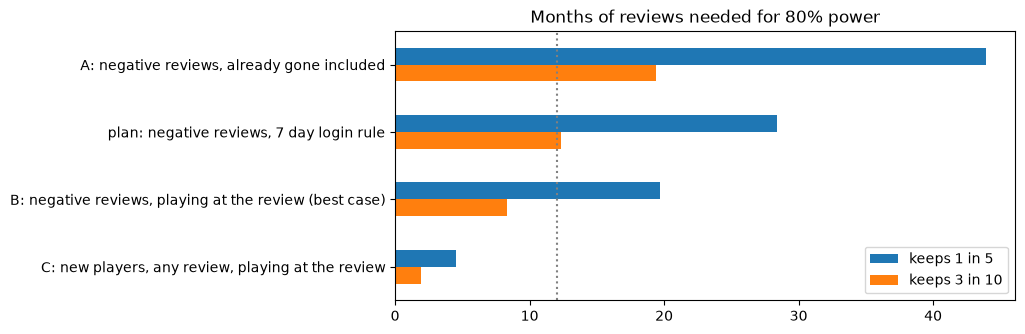

In [12]:
all_new = d[new_player & ~protest]
all_new_still = all_new[all_new["group"] != "already gone"]
share_new = len(all_new_still) / len(all_new)
base_new = KaplanMeierFitter().fit(all_new_still["T"], all_new_still["event"]).predict(90)
size_new = lambda k: per_group(base_new, k * (1 - base_new))
print(f"all new reviewers: already gone {1 - share_new:.1%}, day 90 if still playing {base_new:.1%}, "
      f"about {830 * share_new:.0f} of 830 a month still playing at the review")

rows = {"A: negative reviews, already gone included": [months(size_all(k), 1) for k in (0.2, 0.3)],
        "plan: negative reviews, 7 day login rule": [months(size_plan(k), SHARE7) for k in (0.2, 0.3)],
        "B: negative reviews, playing at the review (best case)": [months(size_live(k), SHARE_STILL) for k in (0.2, 0.3)],
        "C: new players, any review, playing at the review": [2 * size_new(k) / (830 * share_new) for k in (0.2, 0.3)]}
mo = pd.DataFrame(rows, index=["keeps 1 in 5", "keeps 3 in 10"]).T.round(1)
print(mo.to_string())
print(f"plan, 3 in 10: {size_plan(0.3):,.0f} per group; players collected in {months(size_plan(0.3), SHARE7):.1f} months "
      f"(about a year), the answer three months later; exactly 12 months needs {next(k for k in np.linspace(0.2, 0.4, 2001) if months(size_plan(k), SHARE7) <= 12):.3f}")
print(f"3 in 10 lifts day 90 by {100 * 0.3 * leave90:.1f} points, {0.3 * leave90 / gap:.1f} times the whole thumbs gap")

mo.plot.barh(figsize=(8, 3.5), title="Months of reviews needed for 80% power")
plt.axvline(12, color="grey", linestyle=":")
plt.gca().invert_yaxis()
plt.show()

The pooled baseline against recent reviewers, and the three weeks after the protest week (the rest of the 2022 protest wave).

In [13]:
print(f"the baseline pools start years {still['start'].dt.year.min()} to {still['start'].dt.year.max()}")
recent_still = still[still["start"] >= "2023-01-01"]
print(f"still playing at day 90 since 2023: {KaplanMeierFitter().fit(recent_still['T'], recent_still['event']).predict(90):.1%} (pooled {BASE_STILL:.1%})")
by_month = target.groupby(target["start"].dt.to_period("M")).size()
print(f"negative reviews from new players, a month, January to July 2025: {by_month[(by_month.index.year == 2025) & (by_month.index.month <= 7)].mean():.0f}")
tail = (still["start"] >= "2022-08-01") & (still["start"] < "2022-08-22")
print(f"day 90 share without the three weeks after the protest week: "
      f"{KaplanMeierFitter().fit(still.loc[~tail, 'T'], still.loc[~tail, 'event']).predict(90):.1%}")

the baseline pools start years 2017 to 2025
still playing at day 90 since 2023: 76.8% (pooled 79.8%)
negative reviews from new players, a month, January to July 2025: 245
day 90 share without the three weeks after the protest week: 78.6%


## 6. Checking the arithmetic by simulation
Best case, help keeps 3 in 10 leavers: draw real players at random, run 2,000 fake experiments per size.

In [14]:
T, event = pool["T"].values, pool["event"].values
rng = np.random.default_rng(7)
for n in (300, 600):
    found = 0
    for _ in range(2000):
        no_help, helped = rng.integers(0, len(T), n), rng.integers(0, len(T), n)
        share_no = (T[no_help] >= 90).mean()
        kept = (T[helped] < 90) & (event[helped] == 1) & (rng.random(n) < 0.3)
        share_help = ((T[helped] >= 90) | kept).mean()
        both = (share_no + share_help) / 2
        found += abs(share_help - share_no) / np.sqrt(2 * both * (1 - both) / n) > norm.ppf(0.975)
    print(f"{n} per group: the test found the effect in {found / 2000:.0%} of 2,000 experiments")
print(f"the formula: {size_live(0.3):.0f} per group for 80% power; on the plan's 7 day rule {size_plan(0.3):,.0f}")

300 per group: the test found the effect in 49% of 2,000 experiments


600 per group: the test found the effect in 79% of 2,000 experiments
the formula: 605 per group for 80% power; on the plan's 7 day rule 994


## 7. What success would be worth
An illustrative range of retained days over the next year, in a large simulated sample. Retained days are the calendar days from the review to the last observed session, capped at the horizon, here 365: they measure how long players stay, not how many days they play. Kept players either stop right after day 90 (cautious) or follow a random stayer's future (generous).

In [15]:
rng = np.random.default_rng(1)
sample = rng.integers(0, len(T), 200000)
T0, e0 = T[sample], event[sample]
kept = (T0 < 90) & (e0 == 1) & (rng.random(len(sample)) < 0.3)
t365 = np.arange(365)
retained = lambda t, e: KaplanMeierFitter().fit(t, e).survival_function_at_times(t365).sum()
no_help = retained(T0, e0)

T_low, e_low = T0.copy(), e0.copy()
T_low[kept], e_low[kept] = 90.0, 1                          # cautious: they stop right after day 90
stayers = np.where(T >= 90)[0]
borrowed = rng.choice(stayers, kept.sum())                  # generous: each takes a stayer's future
T_high, e_high = T0.copy(), e0.copy()
T_high[kept], e_high[kept] = T[borrowed], event[borrowed]
print(f"retained days over the next year: no help {no_help:.1f}; help, cautious {retained(T_low, e_low):.1f} "
      f"(+{retained(T_low, e_low) - no_help:.1f}); help, generous {retained(T_high, e_high):.1f} (+{retained(T_high, e_high) - no_help:.1f})")

arrive = RATE * SHARE_STILL
print(f"a month: {arrive:.0f} still playing at the review arrive, {arrive * leave90:.0f} leave by day 90; "
      f"3 in 10 keeps {0.3 * arrive * leave90:.0f}, 1 in 5 keeps {0.2 * arrive * leave90:.0f}")

retained days over the next year: no help 272.6; help, cautious 276.8 (+4.2); help, generous 291.2 (+18.6)
a month: 145 still playing at the review arrive, 29 leave by day 90; 3 in 10 keeps 9, 1 in 5 keeps 6


## 8. Reading the result
One simulated best case experiment with 600 per group: an illustration of the readout, not a result.

In [16]:
rng = np.random.default_rng(11)
n = 600
a, b = rng.integers(0, len(T), n), rng.integers(0, len(T), n)
T_a, e_a = T[a], event[a]
T_b, e_b = T[b].copy(), event[b].copy()
kept = (T_b < 90) & (e_b == 1) & (rng.random(n) < 0.3)
borrowed = rng.choice(np.where(T >= 90)[0], kept.sum())
T_b[kept], e_b[kept] = T[borrowed], event[borrowed]

share_a, share_b = (T_a >= 90).mean(), (T_b >= 90).mean()
diff = share_b - share_a
se = np.sqrt(share_a * (1 - share_a) / n + share_b * (1 - share_b) / n)
print(f"day 90: no help {share_a:.1%}, help {share_b:.1%}; lift {100 * diff:.1f} points, 95% CI {100 * (diff - 1.96 * se):.1f} to {100 * (diff + 1.96 * se):.1f} points")
print(f"log rank test across the whole curve: p value {logrank_test(T_a, T_b, e_a, e_b).p_value:.3f}")

day 90: no help 79.7%, help 86.0%; lift 6.3 points, 95% CI 2.1 to 10.6 points
log rank test across the whole curve: p value 0.020


## 9. The plan: the protest wave rule, tested on past weeks
A week with at least 100 negative reviews from new players and over three times the median of the eight weeks before, checked when each week ends.

In [17]:
weekly = all_weeks.groupby(all_weeks["start"].dt.to_period("W")).size()
weekly = weekly.reindex(pd.period_range(weekly.index.min(), weekly.index.max(), freq="W"), fill_value=0)
flag = (weekly >= 100) & (weekly > 3 * weekly.shift(1).rolling(8).median())
print("weeks flagged since 2019:", [str(w) for w in weekly.index[flag & (weekly.index >= pd.Period("2019-01-07", "W"))]])

weeks flagged since 2019: ['2022-07-25/2022-07-31', '2022-08-01/2022-08-07', '2022-08-08/2022-08-14', '2022-08-15/2022-08-21']
